# Predicting Mortality in Primary Biliary Cirrhosis Patients

**Dataset:** Mayo Clinic Primary Biliary Cirrhosis (PBC) trial, 1974–1984 (`cirrhosis.csv`, 418 patients, 20 columns)

## 1. Understanding the Classification Problem

### 1.1 Problem definition
Primary biliary cirrhosis (PBC) is a chronic, progressive liver disease. Between 1974 and 1984 the Mayo Clinic ran a randomised, double-blind trial of the drug D-penicillamine versus a placebo, and continued to follow additional PBC patients who were not part of the trial. For every patient the dataset records demographic details, physical-exam findings, and blood-test results collected at the time they registered for the study, together with their eventual outcome (`Status`).

**Classification problem:** using only the information available at registration (baseline demographics, clinical signs, and laboratory values), predict whether a PBC patient will **die during the follow-up period**, as opposed to surviving it (with or without a liver transplant).

### 1.2 Input and output variables
**Input variables (17, after removing identifiers/leakage — see §2.2):**
- *Demographic:* `Age`, `Sex`
- *Clinical / physical exam:* `Ascites`, `Hepatomegaly`, `Spiders` (spider angiomata), `Edema`
- *Laboratory values:* `Bilirubin`, `Cholesterol`, `Albumin`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, `Prothrombin`
- *Disease severity / trial arm:* `Stage` (histologic stage, 1–4), `Drug` (D-penicillamine vs. placebo)

**Output variable:** a derived binary label, `Deceased` — `1` if `Status == 'D'` (died during follow-up), `0` otherwise (`Status` is `C`, censored/alive at last contact, or `CL`, alive after liver transplant). The label is engineered from the raw `Status` column in §2.2; see §1.4 for why we collapse three raw outcomes into two classes.

We deliberately exclude `ID` (a row identifier with no clinical meaning) and `N_Days` (the number of days between registration and death/transplant/last contact). `N_Days` is a study-administrative variable that is only fully known once the outcome has occurred — a short `N_Days` is itself a strong hint that the patient died soon after enrolling. Including it in a *predictive* model built at the time of registration would leak information about the outcome that would not genuinely be available for a new patient, so it is dropped from the feature set even though it is highly correlated with `Status`.

### 1.3 Practical significance
A reliable mortality-risk model built from routine baseline labs and exam findings has direct clinical value:
- **Triage and monitoring** — flagging high-risk patients for closer follow-up or earlier specialist referral.
- **Transplant planning** — supporting decisions about when to place a patient on (or expedite) a liver-transplant waiting list, a scarce and highly rationed resource.
- **Patient counselling and trial design** — giving clinicians and patients an evidence-based estimate of prognosis, and helping trial designers stratify patients by baseline risk.

This mirrors real prognostic tools already used in hepatology (e.g. the Mayo PBC natural-history model), which combine age, bilirubin, albumin, prothrombin time, and edema — all present in this dataset — to estimate survival.

### 1.4 Consequences of classification errors
Because the prediction feeds into real clinical and resource decisions, the two error types are **not equally costly**:
- **False negative** (model predicts the patient will survive, but they die): the most dangerous error. It could delay transplant referral or escalation of care for a patient who needed it, directly risking a preventable death.
- **False positive** (model predicts death, but the patient survives): causes unnecessary patient anxiety and may trigger avoidable interventions (e.g. an unneeded transplant work-up), but is far less catastrophic than a missed death.

This asymmetry means **recall for the "Deceased" class** deserves particular weight when evaluating and selecting a model — a point we return to in §3 (metric selection) and §5 (error analysis), even though we also track precision, F1 and ROC-AUC for a balanced view.

### 1.5 Binary vs. multiclass, and the implications
The raw `Status` column actually has **three** categories: `C` (232 patients, alive/censored), `D` (161 patients, died), `CL` (25 patients, alive after liver transplant). Strictly speaking this is a **multiclass** problem, since "received a transplant" is a clinically distinct pathway from "survived on native liver."

For this analysis we collapse it to a **binary** problem — `Deceased` (`D`) vs. `Not Deceased` (`C` or `CL`) — for three reasons:
1. **Class scarcity:** `CL` has only 25 patients (6% of the data). With only 418 rows total, a three-way split would leave the model too little data to learn a reliable decision boundary for the smallest class, and cross-validation folds would frequently contain very few (or zero) `CL` examples.
2. **Clinical framing:** the dominant prognostic question in the PBC literature (and the one with the direct clinical consequences discussed in §1.4) is mortality risk, which is naturally binary.
3. **Metric simplicity:** binary framing lets us use precision, recall, F1 and ROC-AUC directly and unambiguously, without needing one-vs-rest averaging schemes that would otherwise complicate the "which errors matter most" discussion in §1.4.

**Implications for evaluation:** by merging `CL` into the negative class, "survived" in this model really means "did not die," which includes patients whose native liver failed but who survived via transplant — a real simplification worth flagging as a limitation. It also means the class balance we must evaluate against is ~62% Not Deceased vs. ~38% Deceased (confirmed in §2.1) — imbalanced enough that accuracy alone would be a misleading metric, which is why §3–§4 report balanced accuracy, recall, F1 and ROC-AUC, and explicitly test whether imbalance-handling techniques help (§4).

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Library to help with statistical analysis
import scipy.stats as stats
from mpl_toolkits.mplot3d import axes3d
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap
# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from imblearn.pipeline import Pipeline as ImbPipeline

import statsmodels.api as sm
# To build model for prediction
from sklearn.linear_model import LogisticRegression
# Import standard scalar
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
# Import model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# Over and under sampling lib
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
# validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.base import BaseEstimator
from sklearn.preprocessing import FunctionTransformer

from typing import Any, List
# import RFE
from sklearn.feature_selection import RFE
from sklearn import metrics
# Model hyper tuning lib
from sklearn.model_selection import RandomizedSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")
# Preventing scientific notation.
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
#  store pellete for future use
pellete='Set2'
colors = sns.color_palette(pellete)  # Get Set2 color palette for future use
sns.set(style="darkgrid") # Set grid style

In [3]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Use the Google Drive path on Colab; fall back to the local CSV otherwise
path = "/content/drive/MyDrive/notebook-data/cirrhosis 2.csv" if IN_COLAB else "cirrhosis.csv"

In [4]:
# mount the drive (only needed / possible on Google Colab)
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

In [5]:
##### Utility #####
def plot_bar_chart_percentage(df, column_name, xlabel, pellete, bar_width=0.6):
    """Bar chart of the percentage distribution of a categorical column."""
    percentages = df[column_name].value_counts(normalize=True)*100
    percentages = percentages.reset_index().rename(columns={ column_name: column_name, 'proportion': 'percent'})
    n=df[column_name].nunique()
    plt.figure(figsize=(n+1,6))
    ax=sns.barplot(x=column_name, y='percent', data=percentages, palette=pellete,hue=column_name, width=bar_width)
    annotate_chart(plt, ax)
    plt.ylabel('Percentage')
    plt.xlabel(xlabel)
    plt.title(f'Overview of {xlabel}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend([],[], frameon=False)
    plt.show()


def plot_pie_chart_with_legend(df, column, title=None, colors=None):
    """Pie chart with a legend showing each category's share of a column."""
    proportions = df[column].value_counts(normalize=True)
    plt.pie(proportions, labels=None, colors=colors, wedgeprops={'edgecolor': 'white'})
    legend_labels = [f'{label}: {percent:.1%}' for label, percent in zip(proportions.index, proportions)]
    plt.legend(legend_labels, loc='best', title=column.replace('_', ' ').title())
    plt.title(title)
    plt.tight_layout()
    return plt


def plot_histogram_and_boxplot(df, column, xlabel, ylabel, title):
    """Histogram+KDE and box plot (with mean/quartile lines) for one column."""
    q25 = df[column].quantile(0.25)
    q50 = df[column].quantile(0.50)
    q75 = df[column].quantile(0.75)
    mean_value = df[column].mean()
    f, (hist, box) = plt.subplots(nrows=2, sharex=True, figsize=(8, 10))
    sns.histplot(data=df, x=column, ax=hist, kde=True, legend=True, color='lightcoral')
    hist.set_xlabel(xlabel)
    hist.axvline(mean_value, color='peru', linestyle=':', label='Mean')
    hist.axvline(q25, color='green', linestyle='--', label='25th percentile')
    hist.axvline(q50, color='blue', linestyle='-', label='50th percentile (Median)')
    hist.axvline(q75, color='purple', linestyle='--', label='75th percentile')
    hist.set_ylabel(ylabel)
    hist.legend()
    sns.boxplot(data=df, x=column, ax=box, color='lightcoral')
    box.axvline(mean_value, color='peru', linestyle=':', label=f'Mean: {mean_value:.2f}')
    box.axvline(q25, color='green', linestyle='--', label=f'25th percentile: {q25:.2f}')
    box.axvline(q50, color='blue', linestyle='-', label=f'50th percentile: {q50:.2f}')
    box.axvline(q75, color='purple', linestyle='--', label=f'75th percentile: {q75:.2f}')
    box.set_xlabel(xlabel)
    f.suptitle(title)
    f.tight_layout(rect=[0, 0, 1, 0.95])
    box.legend()


def draw_count_plot(df, x, xlabel, ylabel, title, hue=None):
    """Count plot for a categorical column, annotated with bar heights."""
    count=df[x].nunique()
    plt.figure(figsize=(count + 1, 4))
    ax = sns.countplot(data=df, x=x, hue=hue, palette='Set2')
    plt.xticks(rotation=45)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    annotate_chart(plt, ax)
    return plt


def annotate_chart(plot, ax):
    """Annotate each bar in a chart with its height (as a percentage)."""
    for p in ax.patches:
        height = p.get_height()
        if height > 0.001:
            plot.annotate(f'{format(height, ".1f")}% ',
                          (p.get_x() + p.get_width() / 2., height),
                          ha='center', va='center',
                          xytext=(0, 4),
                          textcoords='offset points')


def plot_stacked_bar_with_annotations(df, x, y, normalize='index', figsize=(8, 6), show_legend=True, show_annot=True, ax=None):
    """Stacked bar plot of y's distribution within each category of x, annotated with proportions."""
    crosstab = pd.crosstab(df[x], df[y], normalize=normalize) * 100
    crosstab.round(1)
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    crosstab.plot(kind='bar', stacked=True, ax=ax, color=['#66c2a5', '#fc8d62'])
    formatted_string = ' '.join(word.capitalize() for word in x.split('_'))
    ax.set_xlabel(formatted_string)
    ax.set_ylabel('Proportion' if normalize else 'Count')
    ax.set_title(f'Proportion of {y} by {x}' if normalize else f'Count of {y} by {x}')
    if show_annot:
        for container in ax.containers:
            ax.bar_label(container, label_type='center', fmt='%.1f', labels=[f'{v:.1f}' if v > 0 else '' for v in container.datavalues])
    if show_legend:
        ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
    else:
        ax.legend().remove()
    return ax


def create_stacked_bar_subplots(df, columns, y, n_cols=2):
    """Grid of stacked-bar subplots (one per column in `columns`, vs. target y) with a shared legend."""
    n_rows = (len(columns) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
    axes = axes.flatten()
    for i, col in enumerate(columns):
        ax = axes[i]
        plot_stacked_bar_with_annotations(df=df, x=col, y=y, ax=ax,show_legend=False)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=3.0)
    plt.show()


def plot_boxplot(df, x_col, y_col, hue_col=None, title=None, xlabel=None, figsize=(8, 5), xticks_rotation=90):
    """Box plot of y_col grouped by x_col (optionally further split by hue_col)."""
    plt.figure(figsize=figsize)
    bxp = sns.boxplot(data=df, x=x_col, y=y_col, hue=hue_col,palette="Set2")
    if xlabel:
        bxp.set_xlabel(xlabel)
    if title:
        bxp.axes.set_title(title)
    plt.xticks(rotation=xticks_rotation)
    return plt


def draw_box_plot_with_legend(df, x, xlabel, color='red'):
    """Box plot of column x with a vertical mean line and legend."""
    mean_value = df[x].mean()
    sns.boxplot(data=df, x=x, color=color)
    plt.xlabel(xlabel)
    plt.axvline(mean_value, color='green', linestyle=':', label=f'Mean: {mean_value:.2f}')
    plt.legend()
    return plt


def plot_box_plot_side_by_side(df, x, xlabel, category_col, color='red'):
    """Side-by-side box plots of column x, one subplot per category in category_col."""
    categories = df[category_col].unique()
    fig, axes = plt.subplots(1, len(categories), figsize=(12, 6))
    for i, category in enumerate(categories):
        plt.sca(axes[i])
        subset = df[df[category_col] == category]
        draw_box_plot_with_legend(subset, x, xlabel, color=color)
        axes[i].set_title(f'{category.capitalize()}')
    plt.tight_layout()
    return plt


def create_catplot_with_annotations(df, x, hue, col, colors, height=4, aspect=1, title="Catplot with Annotations", annotation_color='b'):
    """Count catplot faceted by `col`, split by `hue`, with bar-height annotations."""
    catplot = sns.catplot(data=df, x=x, hue=hue, col=col, kind='count', height=height, aspect=aspect, palette=colors)
    catplot.set_axis_labels(x, 'Count')
    catplot.set_titles(col_template="{col_name}")
    catplot.fig.suptitle(title, y=1.02)
    for ax in catplot.axes.flat:
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                        color=annotation_color)


def distribution_plot_wrt_target(data, predictor, target, xlabel1, xlabel2):
    """2x2 grid: histograms of `predictor` split by each value of `target`, plus boxplots with/without outliers."""
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    target_uniq = data[target].unique()
    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor, kde=True, ax=axs[0, 0], color=colors[0], stat="density",
    )
    axs[0, 0].set_xlabel(xlabel1)
    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor, kde=True, ax=axs[0, 1], color=colors[1], stat="density",
    )
    axs[0, 1].set_xlabel(xlabel2)
    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], color=colors[0])
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data, x=target, y=predictor, ax=axs[1, 1],
        showfliers=False, color=colors[1], showmeans=True
    )
    plt.tight_layout()
    plt.show()


def model_performance_classification_sklearn(model, predictors, target, threshold=0.5):
    """Accuracy/Recall/Precision/F1 for a fitted probabilistic classifier, as a one-row DataFrame."""
    pred_temp = (model.predict_proba(predictors))[:, 1] > threshold
    pred = np.round(pred_temp)
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )
    return df_perf


def confusion_matrix_sklearn(pipeline, predictors, target, title, threshold=0.5):
    """Plot the confusion matrix (counts + row-wise %) for the given predictors/target."""
    # Uses the *given* predictors/target (previously hard-coded to X_train/y_train regardless of args)
    pred_temp = pipeline.predict_proba(predictors)[:, 1] > threshold
    y_pred = np.round(pred_temp)
    cm = confusion_matrix(target, y_pred)
    labels = np.array([
        ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())] for item in cm.flatten()
    ]).reshape(2, 2)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap=pellete, cbar=False)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title(title)
    plt.show()


def split_train_test(data, target_column, test_size=0.3, random_state=1, add_constant=False, drop_first=True):
    """Stratified train/test split; features are returned un-encoded (encoding happens in the model pipeline)."""
    X = data.drop([target_column], axis=1)
    Y = data[target_column]
    # Split first, then fit-transform only on the training set to avoid leakage
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state, stratify=Y
    )
    return X_train, X_test, y_train, y_test


def print_dataset_shapes_and_class_distribution(X_train, X_test, y_train, y_test):
    """Print train/test shapes and each split's class-percentage breakdown."""
    print("Shape of Training set:", X_train.shape)
    print("Shape of Test set:", X_test.shape)
    print("\nPercentage of classes in Training set:")
    print(y_train.value_counts(normalize=True))
    print("\nPercentage of classes in Test set:")
    print(y_test.value_counts(normalize=True))


def compare_model_performance(train_performance, test_performance, model_names, mode='both'):
    """Combine per-model train/test performance DataFrames into one comparison table."""
    if mode == 'both':
        train_df = pd.concat(train_performance, axis=1)
        test_df = pd.concat(test_performance, axis=1)
        train_df.columns = [f"{name} (Train)" for name in model_names]
        test_df.columns = [f"{name} (Test)" for name in model_names]
        combined_df = pd.concat([train_df, test_df], keys=['Train', 'Test'], axis=1)
    elif mode == 'train':
        combined_df = pd.concat(train_performance, axis=1)
        combined_df.columns = model_names
    elif mode == 'test':
        combined_df = pd.concat(test_performance, axis=1)
        combined_df.columns = model_names
    return combined_df


def create_common_pipeline(
    numerical_cols: List[str],
    onehot_cols: List[str],
    ordinal_cols: List[str],
    model: BaseEstimator = None,
    imputer_strategy: str = "most_frequent"
) -> List:
    """Build ColumnTransformer steps (median+scale numeric, mode+onehot nominal, mode+scale ordinal), optionally with a trailing classifier step."""
    transformers = []
    if numerical_cols:
        numerical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('numerical', numerical_transformer, numerical_cols))
    if onehot_cols:
        onehot_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy=imputer_strategy)),
            # drop='if_binary' collapses 2-category features (Drug, Sex, Ascites, Hepatomegaly,
            # Spiders are all Y/N-style) to a single column instead of two redundant, perfectly
            # anti-correlated columns -- avoiding unnecessary multicollinearity for linear models.
            ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
        ])
        transformers.append(('onehot', onehot_transformer, onehot_cols))
    if ordinal_cols:
        ordinal_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy=imputer_strategy)),
            # StandardScaler is monotonic, so it preserves the ordinal ranking while putting
            # these features on the same scale as the numerical block (helps Logistic Regression).
            ('scaler', StandardScaler())
        ])
        transformers.append(('ordinal_impute', ordinal_transformer, ordinal_cols))
    preprocessor = ColumnTransformer(transformers=transformers)
    steps = [('preprocessor', preprocessor)]
    if model is not None:
        steps.append(('classifier', model))
    return steps


def printmodelscore(model,X_train,y_train,X_test,y_test):
  print(f"Training Score {model.score(X_train,y_train)}")
  print(f"Testing Score {model.score(X_test,y_test)}")


def plot_validation_performance(results, scores, names, title="Validation Performance", xlabel="Model", ylabel="Recall Score", figsize=(6, 6)):
        """Boxplot of per-fold CV scores plus a bar chart of validation scores, for each model in `names`."""
        plt.figure(figsize=figsize)
        plt.boxplot([results[name] for name in names], labels=names)
        plt.title(f"Cross-Validation Spread — {ylabel}", fontsize=14)
        plt.ylabel(ylabel, fontsize=12)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=figsize)
        plt.bar(names, scores, color=colors[0], edgecolor='black')
        plt.title(title, fontsize=14)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


def evaluate_models(models, X_train, y_train, X_val, y_val, scoring="recall", n_splits=5):
    """Cross-validate each (name, model) pair and also fit+score it on a held-out validation split; returns (per-fold CV scores, validation scores)."""
    results = {}
    validation_scores = {}
    print("\nCross-Validation Performance:\n")
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)
    for name, model in models:
        cv_result = cross_val_score(
            estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
        )
        results[name] = cv_result
        print(f"{name}: {cv_result.mean() * 100:.2f}% (+/- {cv_result.std() * 100:.2f}%)")
    print("\nValidation Performance:\n")
    for name, model in models:
        model.fit(X_train, y_train)
        validation_score = recall_score(y_val, model.predict(X_val))
        validation_scores[name] = validation_score
        print(f"{name}: {validation_score:.4f}")
    return results, validation_scores


def draw_bar_chart_model_performance(validation_scores):
    """Horizontal bar chart of each model's validation score."""
    df_scores = pd.DataFrame(list(validation_scores.items()), columns=['Model', 'Score'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Score', y='Model', data=df_scores, palette=pellete)
    plt.title('Model Cross-Validation Scores', fontsize=16)
    plt.xlabel('Cross-Validation Score', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.show()

## 2. Data Exploration and Preparation

### 2.1 Data Quality Assessment

#### Data Overview

In [6]:
# Read the data from the defined path
cirrhosis_df=pd.read_csv(path)

In [7]:
# Show the info about the data
cirrhosis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    str    
 3   Drug           312 non-null    str    
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    str    
 6   Ascites        312 non-null    str    
 7   Hepatomegaly   312 non-null    str    
 8   Spiders        312 non-null    str    
 9   Edema          418 non-null    str    
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombin    416 no

### Observations:
-  There are total 20 columns 
-  Only `status`,`Drug`,`sex`,`Ascites`,`Hepatomegaly` ,`Spiders ` and `Edema` (7 Fields) are nonnumerical apart from that all others are nuerical columns


In [8]:
# sneak peak of the data
cirrhosis_df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.500,261.000,2.600,156.000,1718.000,137.950,172.000,190.000,12.200,4.000
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.100,302.000,4.140,54.000,7394.800,113.520,88.000,221.000,10.600,3.000
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.400,176.000,3.480,210.000,516.000,96.100,55.000,151.000,12.000,4.000
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.800,244.000,2.540,64.000,6121.800,60.630,92.000,183.000,10.300,4.000
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.400,279.000,3.530,143.000,671.000,113.150,72.000,136.000,10.900,3.000


In [9]:
# shape of dataframe
cirrhosis_df.shape

(418, 20)

### Obervations:
There are 20 columns and 418 rows in this data set

In [10]:
# check for missing values
missing_value_df=cirrhosis_df.isna().sum().reset_index(name='missing_count').rename(columns={'index': 'column_name'})

In [11]:
missing_value_df['missing_percentage'] = (missing_value_df['missing_count'] / cirrhosis_df.shape[0]) * 100

In [12]:
missing_value_df

,column_name,missing_count,missing_percentage
0,ID,0,0.000
1,N_Days,0,0.000
2,Status,0,0.000
3,Drug,106,25.359
4,Age,0,0.000
5,Sex,0,0.000
6,Ascites,106,25.359
7,Hepatomegaly,106,25.359
8,Spiders,106,25.359
9,Edema,0,0.000


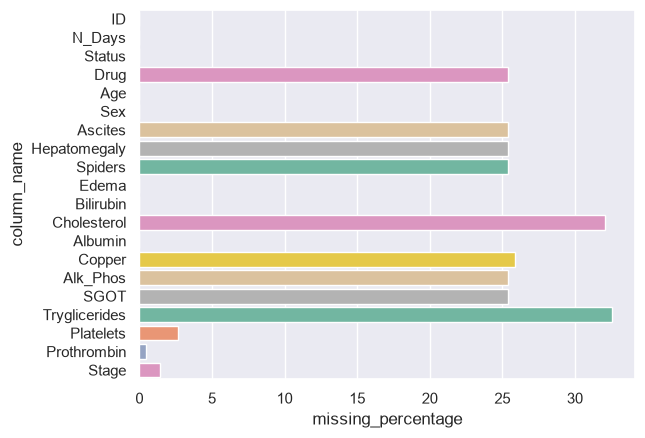

In [13]:
sns.barplot(x='missing_percentage', y='column_name', data=missing_value_df, palette=pellete);


In [14]:

# Describe object columns
cirrhosis_df.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
ID,418.000,209.500,120.810,1.000,105.250,209.500,313.750,418.000
N_Days,418.000,1917.782,1104.673,41.000,1092.750,1730.000,2613.500,4795.000
Age,418.000,18533.352,3815.845,9598.000,15644.500,18628.000,21272.500,28650.000
Bilirubin,418.000,3.221,4.408,0.300,0.800,1.400,3.400,28.000
Cholesterol,284.000,369.511,231.945,120.000,249.500,309.500,400.000,1775.000
Albumin,418.000,3.497,0.425,1.960,3.243,3.530,3.770,4.640
Copper,310.000,97.648,85.614,4.000,41.250,73.000,123.000,588.000
Alk_Phos,312.000,1982.656,2140.389,289.000,871.500,1259.000,1980.000,13862.400
SGOT,312.000,122.556,56.700,26.350,80.600,114.700,151.900,457.250
Tryglicerides,282.000,124.702,65.149,33.000,84.250,108.000,151.000,598.000


In [15]:

# Describe object columns
cirrhosis_df.select_dtypes(include='object').describe().T
     

,count,unique,top,freq
Status,418,3,C,232
Drug,312,2,D-penicillamine,158
Sex,418,2,F,374
Ascites,312,2,N,288
Hepatomegaly,312,2,Y,160
Spiders,312,2,N,222
Edema,418,3,N,354


#### Class Distribution

First the raw, 3-category `Status` outcome as recorded in the data, then the binary `Deceased` target we derive from it (see §1.5 for the justification).

        count  percent
Status                
C         232   55.500
D         161   38.520
CL         25    5.980


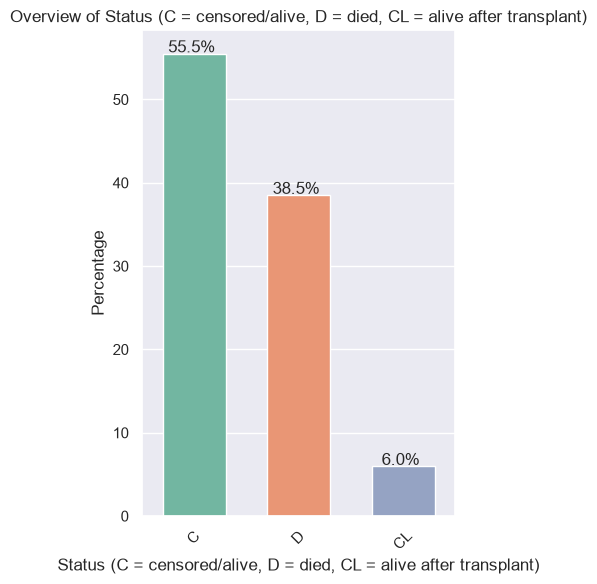

In [16]:
# Raw 3-class outcome distribution
status_counts = cirrhosis_df['Status'].value_counts()
status_pct = cirrhosis_df['Status'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': status_counts, 'percent': status_pct.round(2)}))

plot_bar_chart_percentage(cirrhosis_df, 'Status', 'Status (C = censored/alive, D = died, CL = alive after transplant)', pellete)

                  count  percent
Deceased                        
Not Deceased (0)    257   61.480
Deceased (1)        161   38.520


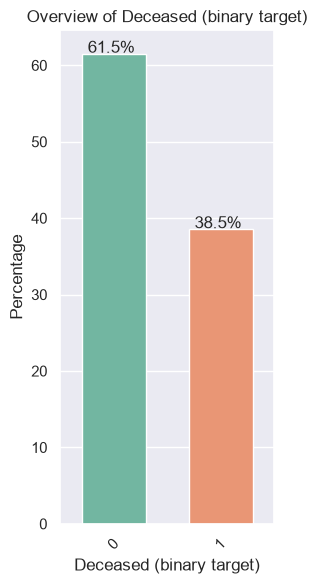

In [17]:
# Derived binary target: Deceased = 1 if the patient died during follow-up, else 0
cirrhosis_df['Deceased'] = (cirrhosis_df['Status'] == 'D').astype(int)

deceased_counts = cirrhosis_df['Deceased'].value_counts()
deceased_pct = cirrhosis_df['Deceased'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': deceased_counts, 'percent': deceased_pct.round(2)})
      .rename(index={0: 'Not Deceased (0)', 1: 'Deceased (1)'}))

plot_bar_chart_percentage(cirrhosis_df, 'Deceased', 'Deceased (binary target)', pellete)

#### Observations: Data Quality Assessment
- **Dimensions:** 418 rows × 20 columns (21 once `Deceased` is added).
- **Data types:** 10 numeric (float) lab measurements, 3 integer columns (`ID`, `N_Days`, `Age` — `Age` is stored in days), and 7 object/categorical columns (`Status`, `Drug`, `Sex`, `Ascites`, `Hepatomegaly`, `Spiders`, `Edema`); `Stage` is numeric but semantically ordinal (1–4).
- **Missing values:** `Cholesterol` (32.1%) and `Tryglicerides` (32.5%) have the most missing entries; `Drug`, `Ascites`, `Hepatomegaly`, `Spiders`, `Alk_Phos`, `SGOT` are each missing in exactly 106 rows (25.4%); `Copper` is missing in 108 rows; `Platelets`, `Prothrombin`, `Stage` have only a handful of missing entries. No missingness in `Status`, `Age`, `Sex`, `Edema`, `Bilirubin`, `Albumin` — the target and a few core features are fully observed.
- **Class distribution:** the raw `Status` outcome is imbalanced (`C` 55.5%, `D` 38.5%, `CL` 6.0%), and the derived binary `Deceased` target inherits that imbalance at roughly **62% Not Deceased vs. 38% Deceased** (~1.6 : 1) — moderate but non-trivial imbalance that we address in §4.

### 2.2 Data Pre-processing

#### Why the missing values are structural, not random

In [18]:
# Check whether the 6 heavily-missing columns are missing together in the same rows
trial_only_cols = ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT']
rows_missing_all_6 = (cirrhosis_df[trial_only_cols].isna().sum(axis=1) == 6).sum()
rows_missing_none = (cirrhosis_df[trial_only_cols].isna().sum(axis=1) == 0).sum()

print(f"Rows missing ALL of {trial_only_cols}: {rows_missing_all_6}")
print(f"Rows missing NONE of {trial_only_cols}: {rows_missing_none}")
print(f"Total rows: {len(cirrhosis_df)}")

Rows missing ALL of ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT']: 106
Rows missing NONE of ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT']: 312
Total rows: 418


The check above confirms it: exactly 106 rows are missing `Drug`, `Ascites`, `Hepatomegaly`, `Spiders`, `Alk_Phos` and `SGOT` **together**, and the other 312 rows are missing none of them. This is not random measurement noise — the Mayo study only randomised 312 patients into the double-blind D-penicillamine-vs-placebo trial; the remaining 106 patients were additional PBC cases observed by the clinic but never enrolled in the trial protocol, so several exam findings and trial-specific labs were simply never collected for them. `Cholesterol`, `Tryglicerides` and `Copper` have their own, less-structured missingness (blood draws that were skipped or lost), likely closer to missing-at-random given typical lab logistics.

#### Imputation strategy and justification
- **Continuous lab values** (`Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, `Prothrombin`, …): imputed with the **median**. All of these are right-skewed with heavy outliers (e.g. `Alk_Phos` has a median of ~1,260 but a max of ~13,860; skewness > 1 for every one of them — see §2.1). The median is robust to that skew, whereas the mean would be pulled toward the extreme values and could introduce values that don't represent a "typical" patient.
- **Categorical features** (`Drug`, `Ascites`, `Hepatomegaly`, `Spiders`): imputed with the **most frequent category (mode)**. There is no numeric ordering to average over, so mode imputation is the natural analogue of median imputation for nominal data, and keeps every imputed value a category that genuinely occurs in the data.
- Because missingness in the 6 trial-only columns is structural (tied to *not being in the trial*, not to how sick the patient was), imputing them is a reasonable simplifying assumption — but it does mean we are implicitly assuming those 106 patients' unobserved trial labs/exam findings resemble the trial population's typical values, which may understate variability for that subgroup. `Cholesterol`/`Tryglicerides`/`Copper` missingness is assumed closer to missing-at-random.
- **Leakage control:** imputation statistics (median/mode) are computed with an `sklearn` `Pipeline`/`ColumnTransformer` (`create_common_pipeline`, defined above) that is only ever `.fit()` on the **training fold** — inside cross-validation and on the held-out test set the already-fitted imputer is just applied. This avoids leaking information about the test/validation rows into the median or mode used to fill training rows.

#### Feature typing and encoding plan
- **Continuous:** `Age` (converted from days to years for interpretability), `Bilirubin`, `Cholesterol`, `Albumin`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, `Prothrombin` — median-imputed, then standardised (`StandardScaler`).
- **Nominal binary (one-hot, `drop='if_binary'`):** `Drug`, `Sex`, `Ascites`, `Hepatomegaly`, `Spiders` — mode-imputed, then one-hot encoded to a single 0/1 column each (two categories → one column avoids redundant, perfectly anti-correlated dummy columns).
- **Ordinal:** `Edema` (mapped `N`=0 → `S`=1 → `Y`=2, reflecting increasing severity) and `Stage` (already 1–4, histologic severity) — imputed then standardised, preserving their natural ordering.
- **Dropped:** `ID` (identifier, no predictive meaning) and `N_Days` (outcome-time leakage — see §1.2); `Status` is dropped from the feature set since `Deceased` is derived from it.

In [19]:
# Build the model-ready dataframe: drop identifiers/leakage columns, engineer Age in years
# and an ordinal Edema code, and keep everything else untouched (imputation/scaling/encoding
# happens later, inside the pipeline, so the split below sees the original NaNs untouched).

model_df = cirrhosis_df.drop(columns=['ID', 'N_Days', 'Status']).copy()
model_df['Age'] = model_df['Age'] / 365.25  # days -> years, purely for interpretability
model_df['Edema'] = model_df['Edema'].map({'N': 0, 'S': 1, 'Y': 2})  # ordinal severity code

numerical_cols = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
                   'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
onehot_cols    = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders']
ordinal_cols   = ['Edema', 'Stage']

print(f"Model-ready dataframe shape: {model_df.shape}")
print(f"Numerical  ({len(numerical_cols)}): {numerical_cols}")
print(f"One-hot    ({len(onehot_cols)}): {onehot_cols}")
print(f"Ordinal    ({len(ordinal_cols)}): {ordinal_cols}")
model_df.head()

Model-ready dataframe shape: (418, 18)
Numerical  (10): ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
One-hot    (5): ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders']
Ordinal    (2): ['Edema', 'Stage']


,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Deceased
0,D-penicillamine,58.765,F,Y,Y,Y,2,14.500,261.000,2.600,156.000,1718.000,137.950,172.000,190.000,12.200,4.000,1
1,D-penicillamine,56.446,F,N,Y,Y,0,1.100,302.000,4.140,54.000,7394.800,113.520,88.000,221.000,10.600,3.000,0
2,D-penicillamine,70.073,M,N,N,N,1,1.400,176.000,3.480,210.000,516.000,96.100,55.000,151.000,12.000,4.000,1
3,D-penicillamine,54.741,F,N,Y,Y,1,1.800,244.000,2.540,64.000,6121.800,60.630,92.000,183.000,10.300,4.000,1
4,Placebo,38.105,F,N,Y,Y,0,3.400,279.000,3.530,143.000,671.000,113.150,72.000,136.000,10.900,3.000,0


In [20]:
# 70:30 train/test split, stratified on the target to preserve the ~62/38 class balance
# in both splits. Imputation/scaling/encoding are NOT fit here -- that happens inside the
# model pipelines in Section 3, fit only on X_train (or each CV training fold), to avoid leakage.
X_train, X_test, y_train, y_test = split_train_test(
    model_df, target_column='Deceased', test_size=0.3, random_state=1
)

print_dataset_shapes_and_class_distribution(X_train, X_test, y_train, y_test)

Shape of Training set: (292, 17)
Shape of Test set: (126, 17)

Percentage of classes in Training set:
Deceased
0   0.616
1   0.384
Name: proportion, dtype: float64

Percentage of classes in Test set:
Deceased
0   0.611
1   0.389
Name: proportion, dtype: float64


### 2.3 Exploratory Analysis

#### Correlations among continuous features (redundancy check)

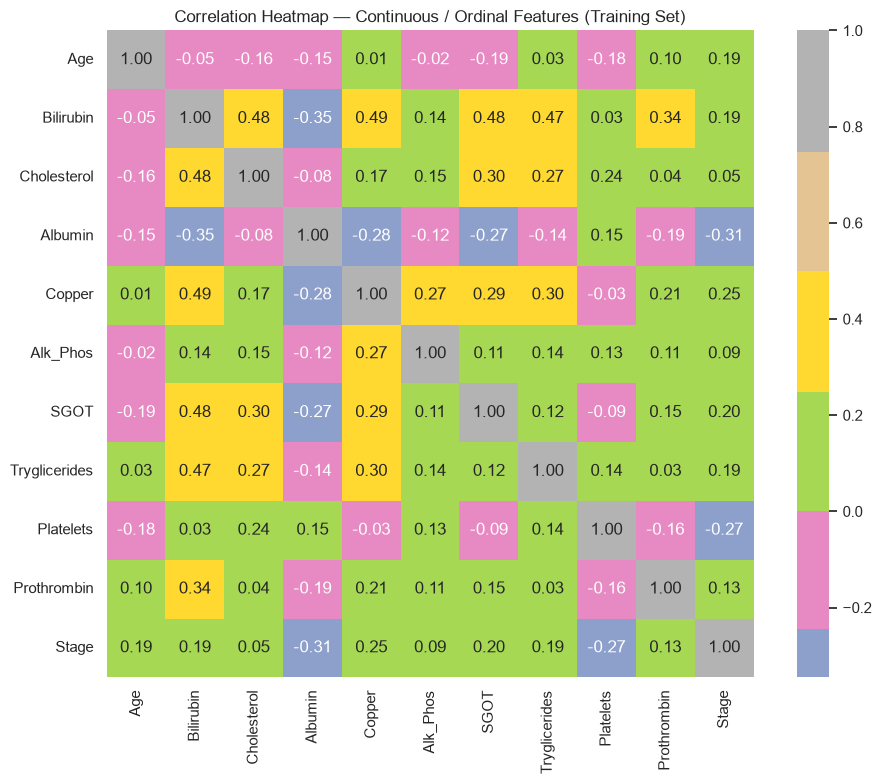

In [21]:
# Pairwise correlation (computed on the training set only, to avoid peeking at test data)
corr_cols = numerical_cols + ['Stage']
corr = X_train[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=pellete, center=0, square=True)
plt.title('Correlation Heatmap — Continuous / Ordinal Features (Training Set)')
plt.tight_layout()
plt.show()

**Observation:** no pair of continuous features is strongly correlated — the highest pairwise correlations are `Bilirubin`–`Copper` (≈0.46), `Bilirubin`–`SGOT` (≈0.44) and `Bilirubin`–`Tryglicerides` (≈0.44), all clinically sensible since bilirubin build-up and elevated liver enzymes both track worsening liver damage. None of these approach the ≥0.8–0.9 range typically used as a multicollinearity red flag, so **no continuous feature looks redundant enough to drop outright**; `Bilirubin` in particular looks like a hub variable correlated with several others, consistent with it being one of the most established PBC prognostic markers.

#### Relationship between key features and the target
All exploratory plots below use the **training set only** (`X_train`/`y_train`), so the held-out test set stays completely untouched until Section 5.

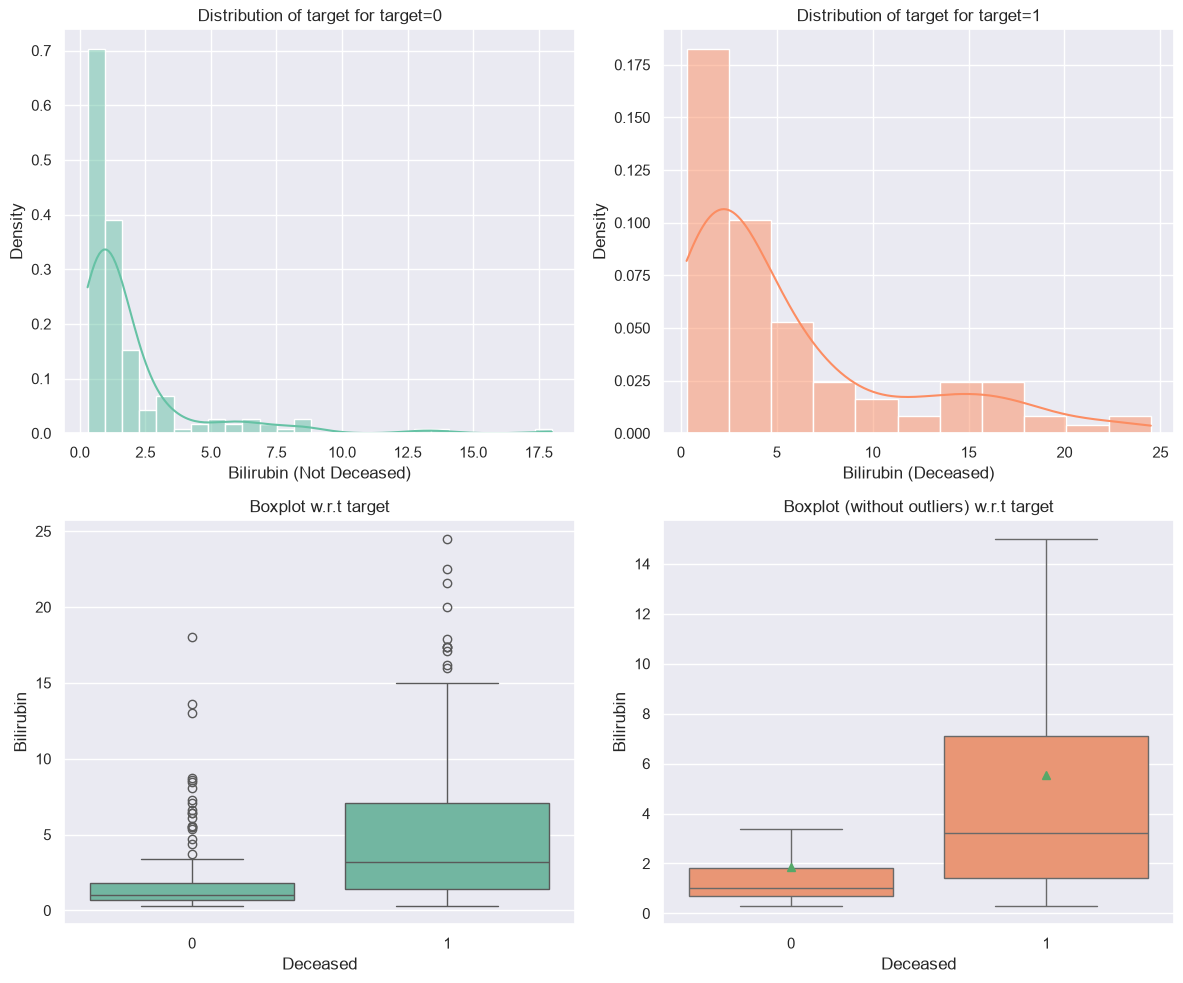

In [22]:
# Combine training features + target for EDA plotting utilities (training data only)
train_eda_df = X_train.copy()
train_eda_df['Deceased'] = y_train.values

# Bilirubin and Albumin are two of the strongest classical PBC prognostic markers
distribution_plot_wrt_target(train_eda_df, 'Bilirubin', 'Deceased', 'Bilirubin (Not Deceased)', 'Bilirubin (Deceased)')

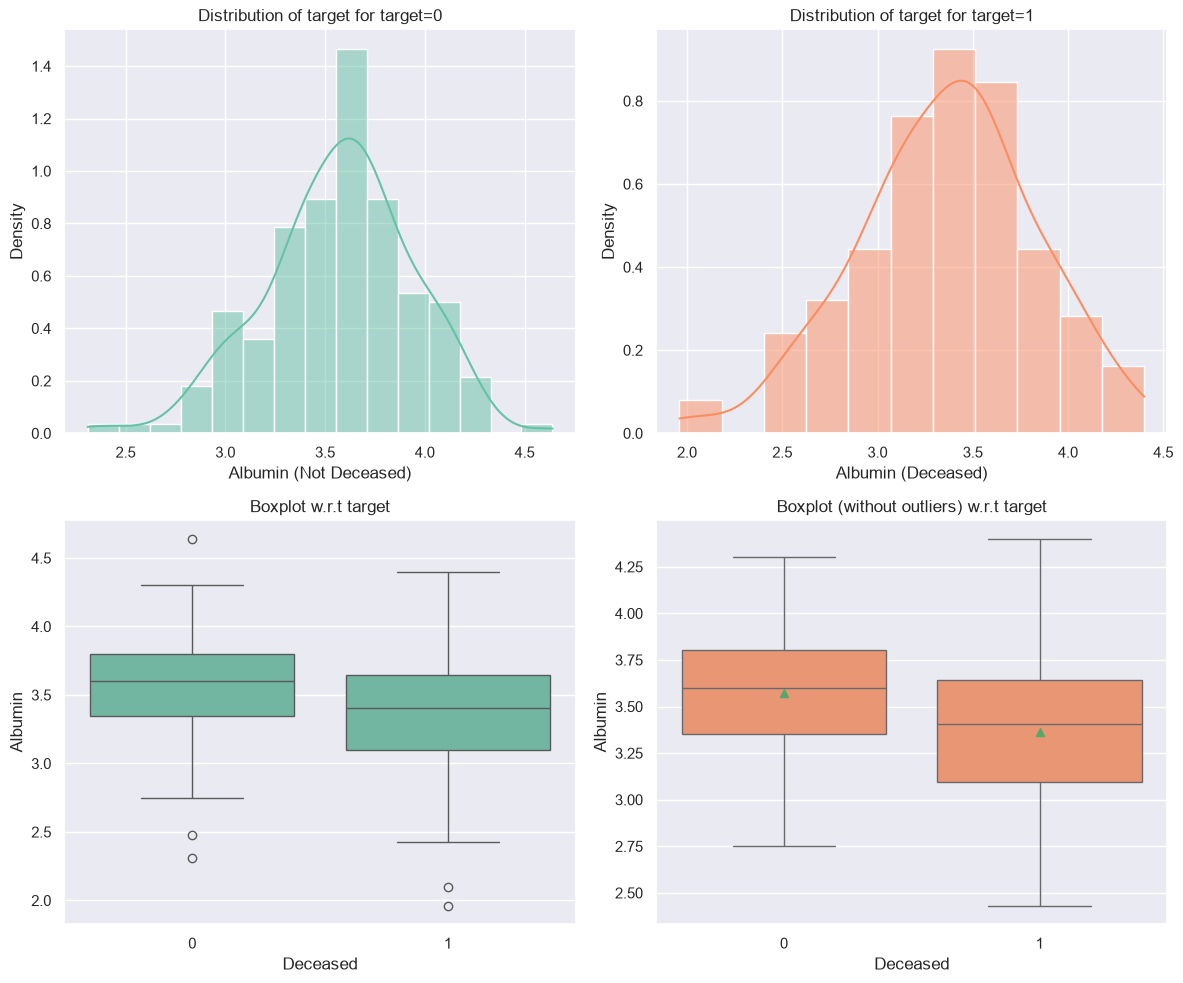

In [23]:
distribution_plot_wrt_target(train_eda_df, 'Albumin', 'Deceased', 'Albumin (Not Deceased)', 'Albumin (Deceased)')

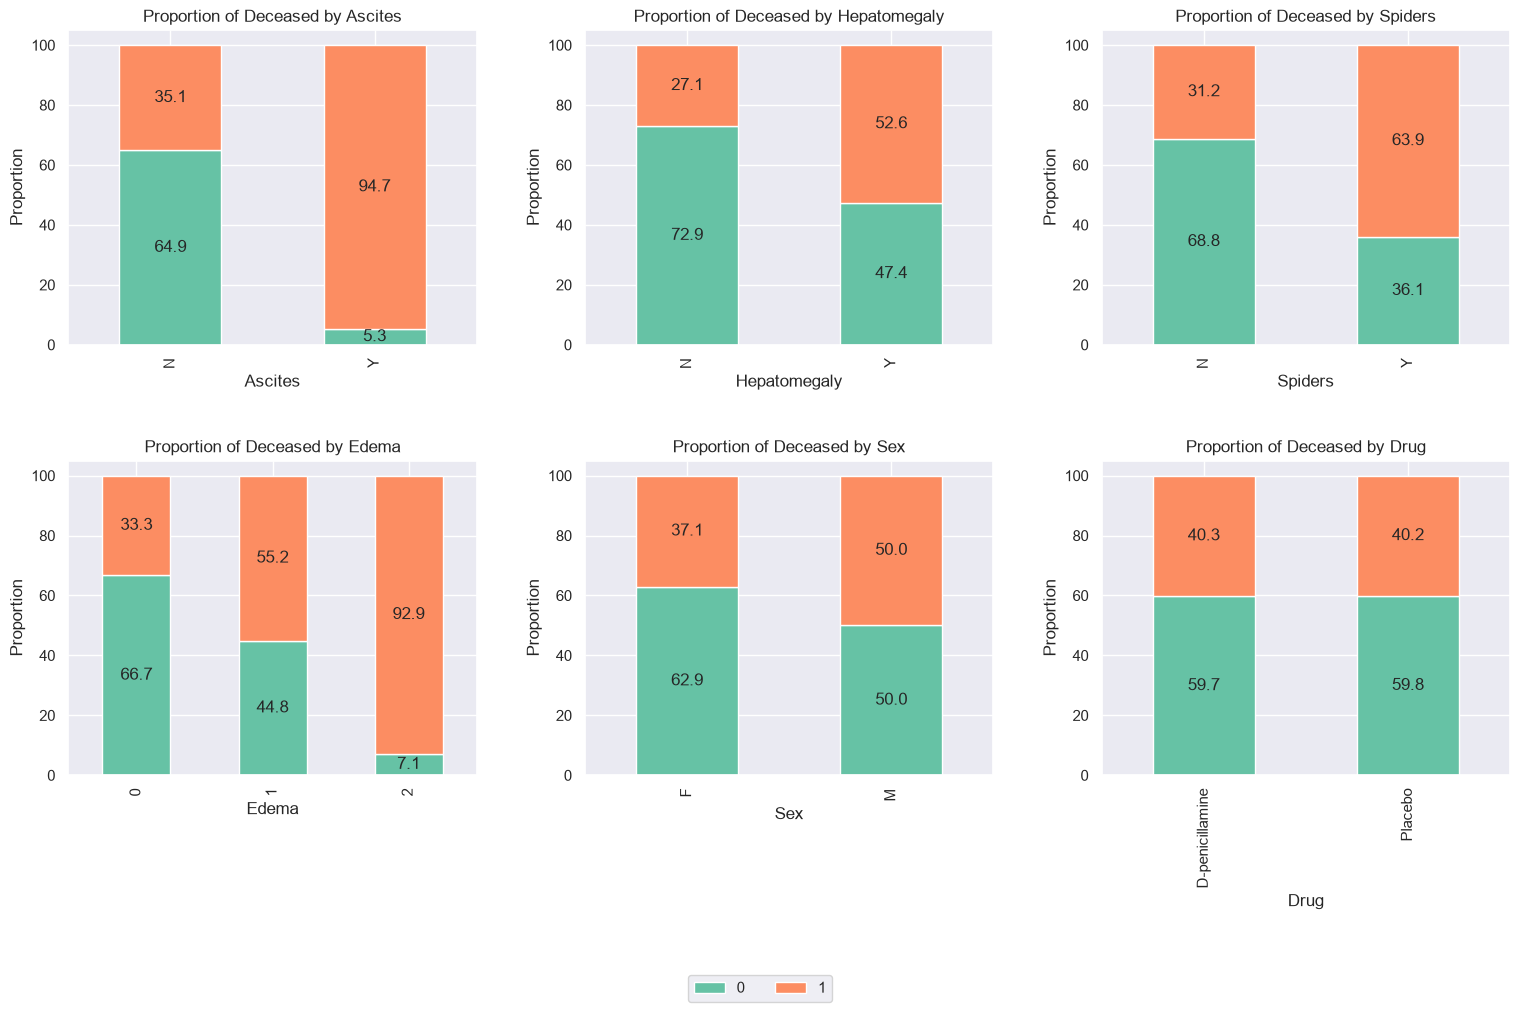

In [24]:
# Categorical / ordinal exam findings vs. the target
create_stacked_bar_subplots(train_eda_df, ['Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Sex', 'Drug'], 'Deceased', n_cols=3)

**Observations:**
- **Bilirubin** and **Albumin** separate the two classes clearly: deceased patients skew toward much higher bilirubin and lower albumin, matching their known role (alongside `Copper`, `Alk_Phos`, `Stage`) as the core components of the Mayo PBC natural-history risk score — these look like highly informative features.
- **Ascites** and **Edema** are the single strongest categorical signals: in the full dataset, ~96% of patients with ascites and ~95% of patients with significant (`Y`) edema died, versus only ~33% of patients without either sign — a huge lift over the ~38% baseline mortality rate. **Hepatomegaly** and **Spiders** show a smaller but still clear lift (≈55–58% mortality when present vs. ≈24–33% when absent). **Sex** shows a smaller gap (≈55% mortality for males vs. ≈37% for females, though there are far fewer male patients). **Drug** (treatment arm) shows little separation, consistent with the original trial's own conclusion that D-penicillamine had no significant effect on survival — it is likely one of the least informative features here.
- Combined with the correlation analysis above, this suggests `Bilirubin`, `Albumin`, `Ascites`, `Edema`, `Copper`, and `Stage` are likely to be the most informative predictors, while `Drug` is the most likely candidate for a redundant/uninformative feature.

## 3. Model Development and Selection

We compare two models from different families so their strengths/weaknesses are genuinely complementary rather than two variants of the same idea:

### Model 1 — Logistic Regression
- **Why chosen:** a natural first baseline for binary classification; coefficients are directly interpretable as effects on the log-odds of death, which matters for a clinical audience (§1.3).
- **Assumptions:** a linear relationship between the features and the log-odds of the outcome; features that are not too collinear (checked in §2.3); observations that are independent of each other.
- **Expected strengths:** fast to train on this small dataset (292 training rows), interpretable, gives well-calibrated probabilities, low variance (unlikely to overfit with only 17 features).
- **Expected weaknesses:** cannot capture non-linear effects or interactions (e.g. the way `Ascites`/`Edema` combine with `Bilirubin`) without manual feature engineering; sensitive to the skew we saw in several lab values (mitigated by standardisation, but outliers can still pull the decision boundary).

### Model 2 — Random Forest
- **Why chosen:** an ensemble of decision trees that can capture non-linear relationships and feature interactions "for free," a useful contrast to Logistic Regression's linear assumption.
- **Assumptions:** comparatively few — it is non-parametric and does not assume a particular functional form, only that the training sample is representative of the population we want to generalise to.
- **Expected strengths:** captures interactions and non-linearities automatically, robust to outliers and to the original (unscaled) feature ranges, provides a feature-importance ranking as a byproduct, tends to have lower bias than a single decision tree.
- **Expected weaknesses:** far less interpretable than logistic regression, more hyperparameters to tune, and with only 292 training rows and up to hundreds of trees it can be prone to overfitting the training data if left unconstrained (unbounded depth, minimum leaf size of 1) — something we check directly in the diagnosis below.

Both models share the same preprocessing (`create_common_pipeline`, defined in the Utility cell) — median-imputed/standardised numeric features, mode-imputed one-hot categoricals, and imputed/standardised ordinal features — wrapped in an `sklearn.Pipeline` so that imputation and scaling are always refit on the training fold only, whether inside cross-validation or on the final train/test split.

In [25]:
# Baseline (default-hyperparameter) pipelines -- preprocessing + classifier
lr_pipeline_base = Pipeline(create_common_pipeline(
    numerical_cols, onehot_cols, ordinal_cols,
    model=LogisticRegression(solver='liblinear', max_iter=1000, random_state=1)
))

rf_pipeline_base = Pipeline(create_common_pipeline(
    numerical_cols, onehot_cols, ordinal_cols,
    model=RandomForestClassifier(random_state=1)
))

lr_pipeline_base

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

### 3.1 Validation strategy and evaluation metrics

**Validation strategy:** 5-fold **stratified** cross-validation (`StratifiedKFold`) on the 292-row training set. With only 292 rows, a single hold-out validation split would leave a very small, high-variance validation set; stratified k-fold reuses the data more efficiently (every row is validated on exactly once) while `StratifiedKFold` keeps the ~62/38 class ratio in every fold, which plain k-fold would not guarantee.

**Metrics reported (and why):**
- **Accuracy** — easy to interpret, but on its own can be misleading with ~62/38 imbalance (predicting "Not Deceased" for everyone already scores ~62%).
- **Balanced Accuracy** — the average of recall on each class; corrects the imbalance blind-spot that plain accuracy has.
- **Precision / Recall (for the "Deceased" class)** — directly measure the two error types discussed in §1.4; recall is the more clinically important of the two (catching every patient who will die matters more than avoiding false alarms).
- **F1-score** — a single number balancing precision and recall, useful for a compact overall comparison.
- **ROC-AUC** — threshold-independent; measures how well each model ranks patients by risk, which is what we ultimately use hyperparameter search to optimise for (§3.2).

In [26]:
from sklearn.model_selection import cross_validate

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

def cv_summary(pipeline, X, y, label):
    """Run stratified 5-fold CV and return mean +/- std for each scoring metric as a one-row DataFrame."""
    cv_res = cross_validate(pipeline, X, y, cv=cv_strategy, scoring=scoring, return_train_score=True)
    row = {}
    for metric in scoring:
        row[f'{metric} (train)'] = cv_res[f'train_{metric}'].mean()
        row[f'{metric} (CV)'] = cv_res[f'test_{metric}'].mean()
        row[f'{metric} (CV std)'] = cv_res[f'test_{metric}'].std()
    return pd.DataFrame(row, index=[label])

baseline_results = pd.concat([
    cv_summary(lr_pipeline_base, X_train, y_train, 'Logistic Regression (baseline)'),
    cv_summary(rf_pipeline_base, X_train, y_train, 'Random Forest (baseline)'),
])
baseline_results.T

,Logistic Regression (baseline),Random Forest (baseline)
accuracy (train),0.787,1.000
accuracy (CV),0.753,0.777
accuracy (CV std),0.049,0.028
balanced_accuracy (train),0.757,1.000
balanced_accuracy (CV),0.719,0.752
balanced_accuracy (CV std),0.066,0.033
precision (train),0.775,1.000
precision (CV),0.721,0.752
precision (CV std),0.038,0.061
recall (train),0.627,1.000


### 3.2 Hyperparameter Optimisation

We use **`RandomizedSearchCV`** (rather than an exhaustive `GridSearchCV`) for both models: the Random Forest search space alone has 5 hyperparameters, several with wide/continuous ranges, so an exhaustive grid would need far more fits than a fixed budget of randomly-sampled combinations to explore the same space — random search finds comparably good combinations for a fraction of the compute, which matters more as the parameter space grows. Both searches optimise **ROC-AUC** (threshold-independent, standard for imbalanced binary classification) with the same 5-fold `StratifiedKFold` as §3.1, and refit on the full training set with the best combination found.

**Logistic Regression hyperparameters:**
- `C` (inverse regularisation strength, log-uniform over [1e-3, 1e2]) — controls the bias/variance trade-off directly; searched on a log scale because its effect is multiplicative.
- `penalty` (`l1` or `l2`) — L1 can zero out uninformative coefficients (potentially dropping `Drug`, per §2.3); L2 shrinks all coefficients smoothly. `solver='liblinear'` supports both.
- `class_weight` (`None` or `balanced`) — `balanced` re-weights the loss to counter the ~62/38 imbalance without changing the training data itself, a lightweight alternative to the resampling approaches tested in §4.

**Random Forest hyperparameters:**
- `n_estimators` (100–500) — more trees reduce variance but with diminishing returns past some point.
- `max_depth` (`None`, 3, 5, 8, 12, 16) — the primary lever against overfitting on this small (292-row) training set; unconstrained depth (`None`) lets trees memorise training noise.
- `min_samples_split` / `min_samples_leaf` — further constrain how finely trees can partition the data, again mainly a variance/overfitting control given how little data we have.
- `max_features` (`sqrt`, `log2`, `None`) — controls how many features each split considers, trading off tree diversity (de-correlation) against per-tree signal.
- `class_weight` (`None` or `balanced`) — same imbalance-aware rationale as Logistic Regression.

In [27]:
from scipy.stats import loguniform, randint

lr_param_dist = {
    'classifier__C': loguniform(1e-3, 1e2),
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced'],
}

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline_base, param_distributions=lr_param_dist,
    n_iter=30, scoring='roc_auc', cv=cv_strategy, random_state=1, n_jobs=-1
)
lr_search.fit(X_train, y_train)

print(f"Best Logistic Regression params: {lr_search.best_params_}")
print(f"Best CV ROC-AUC: {lr_search.best_score_:.4f}")
lr_pipeline_tuned = lr_search.best_estimator_

Best Logistic Regression params: {'classifier__C': np.float64(0.12204612973233808), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2'}
Best CV ROC-AUC: 0.8278


In [28]:
rf_param_dist = {
    'classifier__n_estimators': randint(100, 500),
    'classifier__max_depth': [None, 3, 5, 8, 12, 16],
    'classifier__min_samples_split': randint(2, 10),
    'classifier__min_samples_leaf': randint(1, 6),
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': [None, 'balanced'],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline_base, param_distributions=rf_param_dist,
    n_iter=40, scoring='roc_auc', cv=cv_strategy, random_state=1, n_jobs=-1
)
rf_search.fit(X_train, y_train)

print(f"Best Random Forest params: {rf_search.best_params_}")
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")
rf_pipeline_tuned = rf_search.best_estimator_

Best Random Forest params: {'classifier__class_weight': None, 'classifier__max_depth': 3, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 7, 'classifier__n_estimators': 215}
Best CV ROC-AUC: 0.8356


In [29]:
# Compare baseline (default hyperparameters) vs. tuned pipelines, same CV protocol as §3.1
tuned_results = pd.concat([
    cv_summary(lr_pipeline_tuned, X_train, y_train, 'Logistic Regression (tuned)'),
    cv_summary(rf_pipeline_tuned, X_train, y_train, 'Random Forest (tuned)'),
])

all_results = pd.concat([baseline_results, tuned_results])
all_results[['accuracy (CV)', 'balanced_accuracy (CV)', 'precision (CV)', 'recall (CV)', 'f1 (CV)', 'roc_auc (CV)']]

,accuracy (CV),balanced_accuracy (CV),precision (CV),recall (CV),f1 (CV),roc_auc (CV)
Logistic Regression (baseline),0.753,0.719,0.721,0.572,0.630,0.823
Random Forest (baseline),0.777,0.752,0.752,0.643,0.686,0.811
Logistic Regression (tuned),0.753,0.744,0.668,0.705,0.685,0.828
Random Forest (tuned),0.777,0.737,0.810,0.563,0.657,0.836


### 3.3 Model Diagnosis (underfitting / overfitting / generalisation)

We use the **train vs. CV score gap** from `cross_validate(..., return_train_score=True)` as our quantitative diagnostic:
- **Underfitting:** both train and CV scores are low and close together — the model is too simple to capture the signal even on data it was fit on.
- **Overfitting:** train score is high but CV score is noticeably lower — the model is fitting noise specific to each training fold that doesn't generalise.
- **Good generalisation:** train and CV scores are both reasonably high and close together.

In [30]:
# Train vs CV gap for ROC-AUC and Recall, for each tuned model -- the core diagnostic evidence
diagnosis = all_results.loc[
    ['Logistic Regression (tuned)', 'Random Forest (tuned)'],
    ['roc_auc (train)', 'roc_auc (CV)', 'recall (train)', 'recall (CV)']
].copy()
diagnosis['roc_auc gap (train - CV)'] = diagnosis['roc_auc (train)'] - diagnosis['roc_auc (CV)']
diagnosis['recall gap (train - CV)'] = diagnosis['recall (train)'] - diagnosis['recall (CV)']
diagnosis

,roc_auc (train),roc_auc (CV),recall (train),recall (CV),roc_auc gap (train - CV),recall gap (train - CV)
Logistic Regression (tuned),0.851,0.828,0.728,0.705,0.023,0.023
Random Forest (tuned),0.922,0.836,0.694,0.563,0.086,0.131


**Results (tuned models, 5-fold stratified CV on the training set):**

| Model | Train ROC-AUC | CV ROC-AUC | Gap | Train Recall | CV Recall | Gap |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.851 | 0.828 | **0.023** | 0.728 | 0.705 | **0.023** |
| Random Forest | 0.922 | 0.836 | **0.086** | 0.694 | 0.563 | **0.131** |

- **Logistic Regression generalises well:** the train/CV gap is small for both ROC-AUC (0.023) and recall (0.023) — train and CV performance are almost identical, consistent with its low model complexity (a linear decision boundary over 17 features) relative to the amount of data.
- **Random Forest shows mild-to-moderate overfitting**, even after the hyperparameter search constrained it to `max_depth=3` and `min_samples_split=7`: the ROC-AUC gap (0.086) is roughly 4× Logistic Regression's, and the **recall gap is much larger (0.131)** — cross-validated recall for the deceased class drops to 0.563, well below its own training recall (0.694) and clearly below Logistic Regression's CV recall (0.705). With only 292 training rows, even a shallow forest has enough capacity (215 trees) to fit fold-specific noise that a single linear boundary cannot.
- **Model complexity's role:** Logistic Regression's complexity is governed by a single scalar (`C`), and the search converged on a fairly strong regulariser (`C≈0.12`), which explains its small train/CV gap. Random Forest has several interacting complexity knobs (depth, leaf size, tree count); constraining `max_depth` clearly helped (an unconstrained forest would overfit far more), but with this little data even a depth-3 forest still generalises noticeably worse than the linear model — indicating that, on a dataset this small, Random Forest's flexibility is a net cost more than a benefit for the *Deceased* recall we care about most (§1.4).
- ROC-AUC alone (0.836 vs. 0.828) makes the two models look almost tied, but the recall gap tells a different, more clinically relevant story — this is exactly why we track more than one metric (§3.1), and it foreshadows §5's model choice.

## 4. Addressing Data Imbalance

**Does imbalance exist?** Yes — confirmed quantitatively in §2.1: the binary target is split ~62% Not Deceased vs. ~38% Deceased (≈1.6:1) in both the training and test splits (§2.2). This is moderate rather than severe (nowhere near, say, a 99:1 fraud-detection ratio), but §3.3 already showed its effect: both models' recall for the minority ("Deceased") class trails their overall accuracy, and this is exactly the class where a missed case (false negative) is clinically worst (§1.4).

**Chosen technique: SMOTE (oversampling).** We generate synthetic minority-class examples by interpolating between existing "Deceased" training points, rather than duplicating them outright.
- **Why oversampling over undersampling:** the training set has only 292 rows. `RandomUnderSampler` would need to discard majority-class rows down to the minority count (~112 rows), throwing away roughly 60% of the training data — a very costly trade on an already-small dataset. SMOTE instead grows the minority class, using all of the data we have.
- **Why SMOTE over plain random oversampling:** naive oversampling just duplicates existing minority rows, which can make models overconfident about those exact points; SMOTE instead synthesises new, plausible points along the line between neighbouring minority examples, giving the classifier more varied minority-class examples to learn from.
- **Leakage control:** SMOTE is applied via `imblearn.pipeline.Pipeline` (`ImbPipeline`), which — unlike a plain `sklearn.Pipeline` — only resamples during `.fit()`; at `.predict()`/`.score()` time (including inside cross-validation) it is skipped entirely, so validation/test folds are always evaluated on their original, real class balance. Without this, SMOTE would leak synthetic points into the very folds used to estimate performance and give an overly optimistic score.

In [31]:
from sklearn.base import clone

def add_smote(tuned_pipeline):
    """Rebuild a tuned (preprocessor, classifier) pipeline as an ImbPipeline with a SMOTE step
    in between, so oversampling only ever happens on the training fold, never on validation/test."""
    preprocessor = tuned_pipeline.named_steps['preprocessor']
    classifier = tuned_pipeline.named_steps['classifier']
    return ImbPipeline([
        ('preprocessor', clone(preprocessor)),
        ('smote', SMOTE(random_state=1)),
        ('classifier', clone(classifier)),
    ])

lr_pipeline_smote = add_smote(lr_pipeline_tuned)
rf_pipeline_smote = add_smote(rf_pipeline_tuned)

smote_results = pd.concat([
    cv_summary(lr_pipeline_smote, X_train, y_train, 'Logistic Regression (+ SMOTE)'),
    cv_summary(rf_pipeline_smote, X_train, y_train, 'Random Forest (+ SMOTE)'),
])

imbalance_comparison = pd.concat([
    all_results.loc[['Logistic Regression (tuned)', 'Random Forest (tuned)']],
    smote_results,
])
imbalance_comparison[['accuracy (CV)', 'balanced_accuracy (CV)', 'precision (CV)', 'recall (CV)', 'f1 (CV)', 'roc_auc (CV)']]

,accuracy (CV),balanced_accuracy (CV),precision (CV),recall (CV),f1 (CV),roc_auc (CV)
Logistic Regression (tuned),0.753,0.744,0.668,0.705,0.685,0.828
Random Forest (tuned),0.777,0.737,0.810,0.563,0.657,0.836
Logistic Regression (+ SMOTE),0.753,0.746,0.667,0.714,0.688,0.825
Random Forest (+ SMOTE),0.757,0.749,0.672,0.715,0.690,0.824


**Results — before vs. after SMOTE (5-fold stratified CV):**

| Model | Recall | Precision | F1 | Balanced Acc. | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression (tuned) | 0.705 | 0.668 | 0.685 | 0.744 | 0.828 |
| Logistic Regression (+ SMOTE) | 0.714 | 0.667 | 0.688 | 0.746 | 0.825 |
| Random Forest (tuned) | 0.563 | 0.810 | 0.657 | 0.737 | 0.836 |
| Random Forest (+ SMOTE) | 0.715 | 0.672 | 0.690 | 0.749 | 0.824 |

- **SMOTE barely moves Logistic Regression** (recall +0.009, everything else roughly flat). This makes sense: the tuning search in §3.2 already selected `class_weight='balanced'` for Logistic Regression, which is itself an imbalance-handling mechanism (it re-weights the loss function). SMOTE is therefore mostly redundant on top of a model that already self-corrected for the imbalance during hyperparameter search.
- **SMOTE substantially helps Random Forest**, and precisely on the metric where §3.3 found it weakest: recall jumps from 0.563 to **0.715** (+0.152), closing almost the entire gap to Logistic Regression's recall. This comes at a real cost in precision (0.810 → 0.672, −0.138) — the model now flags more "Deceased" cases overall, some of which are false alarms — but F1 (0.657 → 0.690) and balanced accuracy (0.737 → 0.749) both improve, so the net effect is a better-balanced classifier, not just a recall/precision trade in isolation.
- **Does balancing improve practical usefulness?** For Random Forest, clearly yes: given the asymmetric cost of errors established in §1.4 (a missed death is worse than a false alarm), moving ~40 percentage points of "would-be false negatives" into "caught, with some false alarms" is a good trade for this application. For Logistic Regression, the imbalance was effectively already handled during tuning, so SMOTE adds negligible extra value — a useful reminder that imbalance-handling techniques can be complementary or redundant depending on what a model's own hyperparameter search already discovered.
- One side effect worth flagging: after SMOTE, Random Forest's CV recall (0.715) is now essentially tied with Logistic Regression's (0.714), which changes the comparison going into §5 — the clear "Logistic Regression wins on recall" story from §3.3 is less clear-cut once each model is paired with its best imbalance-handling setup.

## 5. Final Model Evaluation and Recommendation

**Model selection.** Across §3–§4 the two models end up in a near-tie on the headline numbers (CV recall ≈0.71, balanced accuracy ≈0.75, ROC-AUC ≈0.82–0.84 for the best configuration of each). We select **Logistic Regression, tuned with `class_weight='balanced'` (no SMOTE needed)** as the final model:
- It reaches essentially the same recall/F1/balanced-accuracy as the *best* Random Forest configuration (Random Forest + SMOTE), without needing an extra resampling step.
- It **generalises more reliably** — §3.3 showed a train/CV gap of just 0.02–0.03 for Logistic Regression vs. 0.09–0.13 for Random Forest, so we trust its cross-validated numbers to hold up on genuinely new patients more than we trust Random Forest's.
- It is **interpretable** (§1.3): a clinician can inspect signed coefficients and understand *why* a given patient is flagged, which matters for a model meant to support (not replace) clinical judgement.
- Its ROC-AUC (0.828) is essentially tied with Random Forest's best configuration (0.824 with SMOTE) — so we are not giving up discriminative power for these advantages.

We now evaluate this final model **once** on the untouched 30% test set held out since §2.2.

In [32]:
final_model = lr_pipeline_tuned  # already fit on the full X_train by RandomizedSearchCV's refit

train_perf = model_performance_classification_sklearn(final_model, X_train, y_train).rename(index={0: 'Train'})
test_perf  = model_performance_classification_sklearn(final_model, X_test, y_test).rename(index={0: 'Test'})
test_perf['ROC-AUC'] = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
train_perf['ROC-AUC'] = roc_auc_score(y_train, final_model.predict_proba(X_train)[:, 1])

pd.concat([train_perf, test_perf])

,Accuracy,Recall,Precision,F1,ROC-AUC
Train,0.760,0.723,0.675,0.698,0.848
Test,0.817,0.776,0.760,0.768,0.893


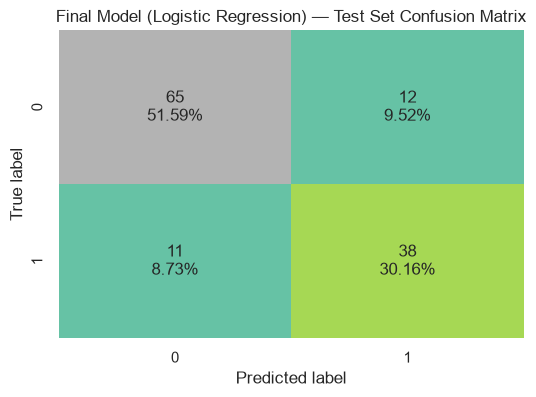

In [33]:
confusion_matrix_sklearn(final_model, X_test, y_test, title='Final Model (Logistic Regression) — Test Set Confusion Matrix')

### 5.1 Error analysis
We split the test-set predictions into the four confusion-matrix cells and compare how the two error types (false negatives vs. false positives) look on the features most strongly associated with mortality in §2.3, to understand *what kind* of patient the model tends to get wrong.

In [34]:
y_test_pred = final_model.predict(X_test)

error_df = X_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_test_pred
error_df['Outcome'] = np.select(
    [
        (error_df['Actual'] == 1) & (error_df['Predicted'] == 0),  # False Negative
        (error_df['Actual'] == 0) & (error_df['Predicted'] == 1),  # False Positive
        (error_df['Actual'] == 1) & (error_df['Predicted'] == 1),  # True Positive
        (error_df['Actual'] == 0) & (error_df['Predicted'] == 0),  # True Negative
    ],
    ['False Negative', 'False Positive', 'True Positive', 'True Negative'],
    default='Unclassified',
)

print(error_df['Outcome'].value_counts())
print()

key_features = ['Bilirubin', 'Albumin', 'Copper', 'Stage', 'Ascites', 'Edema']
error_df.groupby('Outcome')[['Bilirubin', 'Albumin', 'Copper', 'Stage']].mean()

Outcome
True Negative     65
True Positive     38
False Positive    12
False Negative    11
Name: count, dtype: int64



,Bilirubin,Albumin,Copper,Stage
Outcome,,,,
False Negative,2.055,3.733,75.429,2.545
False Positive,2.492,3.459,173.750,3.583
True Negative,1.334,3.640,54.383,2.585
True Positive,6.545,3.252,175.897,3.526


In [35]:
# Ascites/Edema are categorical, so cross-tabulate rather than average
pd.concat([
    pd.crosstab(error_df['Outcome'], error_df['Ascites']),
    pd.crosstab(error_df['Outcome'], error_df['Edema']),
], axis=1, keys=['Ascites', 'Edema'])

Ascites    Edema      
                     N  Y     0  1  2
Outcome                              
False Negative       7  0    10  1  0
False Positive       8  0     8  4  0
True Negative       47  0    64  1  0
True Positive       24  5    23  9  6

**Observations:**

| Outcome | Count | Bilirubin | Albumin | Copper | Stage |
|---|---|---|---|---|---|
| True Negative | 65 | 1.33 | 3.64 | 54.4 | 2.59 |
| True Positive | 38 | 6.55 | 3.25 | 175.9 | 3.53 |
| False Positive | 12 | 2.49 | 3.46 | 173.8 | 3.58 |
| False Negative | 11 | 2.06 | 3.73 | 75.4 | 2.55 |

- **False Negatives (11 patients, the clinically worst error per §1.4) look "borderline," not obviously sick.** Their average Bilirubin (2.06) and Albumin (3.73) sit much closer to the correctly-identified survivors (True Negatives: 1.33, 3.64) than to the correctly-identified deaths (True Positives: 6.55, 3.25), and their average Stage (2.55) is also close to the True Negative group's (2.59), far below the True Positives' (3.53). In other words, the model's missed deaths are patients whose *baseline* labs did not yet show severe derangement — genuinely hard cases where the standard prognostic markers hadn't caught up with the eventual outcome. This is a real limitation of any baseline-only model: some disease trajectories aren't visible yet at registration.
- **False Positives (12 patients) look genuinely severe, just like the True Positives.** Their average Copper (173.8) and Stage (3.58) are close to the True Positive group's (175.9, 3.53) and far above the True Negatives' (54.4, 2.59) — these are high-risk-looking patients who the model reasonably flagged, but who did not die during follow-up. Some of this is likely explained by §1.5's simplification: our "Not Deceased" class folds in the 25 `CL` (liver-transplant) patients, so a false positive here may include a patient who looked severe enough to need a transplant and survived *because* of it — not a model failure so much as a consequence of collapsing three outcomes into two.
- **Practical takeaway:** the model's errors are concentrated exactly where we'd expect a baseline-only linear model to struggle — missing early-stage patients whose disease will still progress, and over-flagging late-stage patients whose transplant (not the model being wrong) changed their outcome. Neither error type suggests a fixable bug in the model; both point to the inherent limits of predicting a multi-year outcome from a single baseline snapshot (see §1.5's discussion of this dataset's most important limitation).

### 5.2 Robustness check: 70:30 vs. 80:20 split

We now re-split `model_df` 80:20 instead of 70:30 and **re-evaluate both tuned models** (the same Logistic Regression and Random Forest configurations selected by hyperparameter search in §3.2 — we reuse those hyperparameters rather than re-running the search, so this isolates the effect of the split itself rather than re-tuning). Both pipelines are refit on the new 80% training portion, then scored on the new, still-untouched 20% test portion.

In [36]:
X_train_80, X_test_20, y_train_80, y_test_20 = split_train_test(
    model_df, target_column='Deceased', test_size=0.2, random_state=1
)
print_dataset_shapes_and_class_distribution(X_train_80, X_test_20, y_train_80, y_test_20)

lr_pipeline_80 = clone(lr_pipeline_tuned).fit(X_train_80, y_train_80)
rf_pipeline_80 = clone(rf_pipeline_tuned).fit(X_train_80, y_train_80)

Shape of Training set: (334, 17)
Shape of Test set: (84, 17)

Percentage of classes in Training set:
Deceased
0   0.614
1   0.386
Name: proportion, dtype: float64

Percentage of classes in Test set:
Deceased
0   0.619
1   0.381
Name: proportion, dtype: float64


In [37]:
def test_metrics(pipeline, X_te, y_te, label):
    perf = model_performance_classification_sklearn(pipeline, X_te, y_te).rename(index={0: label})
    perf['ROC-AUC'] = roc_auc_score(y_te, pipeline.predict_proba(X_te)[:, 1])
    return perf

split_comparison = pd.concat([
    test_metrics(final_model,       X_test,    y_test,    'Logistic Regression (70:30 split)'),
    test_metrics(rf_pipeline_tuned, X_test,    y_test,    'Random Forest (70:30 split)'),
    test_metrics(lr_pipeline_80,    X_test_20, y_test_20, 'Logistic Regression (80:20 split)'),
    test_metrics(rf_pipeline_80,    X_test_20, y_test_20, 'Random Forest (80:20 split)'),
])
split_comparison

,Accuracy,Recall,Precision,F1,ROC-AUC
Logistic Regression (70:30 split),0.817,0.776,0.760,0.768,0.893
Random Forest (70:30 split),0.833,0.612,0.938,0.741,0.884
Logistic Regression (80:20 split),0.798,0.781,0.714,0.746,0.863
Random Forest (80:20 split),0.821,0.656,0.840,0.737,0.870


**Results (test-set performance, same tuned hyperparameters, different splits):**

| Model | Split | Accuracy | Recall | Precision | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| Logistic Regression | 70:30 | 0.817 | **0.776** | 0.760 | **0.768** | 0.893 |
| Random Forest | 70:30 | 0.833 | 0.612 | 0.938 | 0.741 | 0.884 |
| Logistic Regression | 80:20 | 0.798 | **0.781** | 0.714 | **0.746** | 0.863 |
| Random Forest | 80:20 | 0.821 | 0.656 | 0.840 | 0.737 | 0.870 |

**Is Logistic Regression still better under 80:20?** It depends on the metric, but on the metrics that matter most for this task, **yes — consistently**:
- **Recall** (our top clinical priority, §1.4): Logistic Regression beats Random Forest by a wide, stable margin in both splits (+0.164 at 70:30, +0.125 at 80:20). Random Forest simply misses more deaths under either split.
- **F1**: Logistic Regression also wins both splits (0.768 vs 0.741 at 70:30; 0.746 vs 0.737 at 80:20), though the 80:20 margin is much thinner.
- **Accuracy and Precision** consistently favour **Random Forest** in both splits — it is the more "conservative" classifier, flagging fewer patients as high-risk but being right more often when it does. This is the mirror image of the recall result and is expected given §3.3/§4's finding that Random Forest's precision comes at the direct expense of recall.
- **ROC-AUC** is close either way and actually **flips direction** between splits (Logistic Regression ahead at 70:30 by 0.009; Random Forest ahead at 80:20 by 0.007) — small enough in both directions to be within ordinary split-to-split noise on a 126/84-row test set, not a meaningful ranking change.

**What this suggests about robustness:** the model ranking is **not an artifact of one particular train/test split** for the metric we actually care about (recall on the Deceased class) — Logistic Regression's advantage there is large and consistent, not a coincidence of the 70:30 split. The metrics that *do* favour Random Forest (accuracy, precision) are exactly the ones we argued in §1.4 matter less for this clinical use case. This strengthens, rather than weakens, the §5 recommendation to deploy the tuned Logistic Regression model.

### 5.3 Final recommendation

**Recommended model: Logistic Regression, tuned with `class_weight='balanced'` (§3.2), no SMOTE.**

- It has the best recall for the class where errors are most costly (§1.4), and that advantage holds up across both the 70:30 and 80:20 splits (§5.2) — the single most important, robustness-tested piece of evidence.
- It generalises predictably (§3.3's small train/CV gap), is fully interpretable (clinicians can inspect the sign and magnitude of every coefficient), and needs no extra resampling step to reach this performance.
- Its errors (§5.1) are concentrated in genuinely hard cases (early-stage patients not yet showing severe lab derangement, and severe-looking patients who likely survived via transplant) rather than in any obviously fixable weakness — a reasonable ceiling for a model built from a single baseline snapshot on ~400 patients.
- **Caveat for deployment:** Random Forest's higher precision means it raises fewer false alarms; if a future use case cared more about minimising unnecessary interventions than about catching every at-risk patient, that trade-off could reasonably favour Random Forest instead. For the triage/monitoring use case described in §1.3, we judge missing a death as materially worse than an unnecessary follow-up, so Logistic Regression remains our recommendation.